In [30]:
# TP01 - UN PRIMER ENCUENTRO CON LA EPH – [Taller de Programación]
## Alumnos:  Kostzer Federico - Meza Palma Manuel Humberto - Pardini Maximiliano Gabriel - 
## Fecha: 6/10/2025

# Parte 1 - Familiarizandonos con la base EPH y limpieza

2.a. A partir de ahora, cada grupo debe decidir trabajar con una región del país en específico y mantener dicha región en los próximos trabajos prácticos (ver variable REGION). Eliminen los datos de todas aquellas regiones que no se encuentren dentro de su región y unan ambos trimestres (2005 y 2025) en una sola base. 

In [1]:
!pip install openpyxl

In [2]:
# ==========================================================
# IMPORTAR LIBRERÍAS
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# ==========================================================
# 1️⃣ CARGAR BASES DE DATOS
# ==========================================================

# Rutas de archivos
ruta_2005 = r"C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3\TP01\usu_individual_T105.dta"
ruta_2025 = r"C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3\TP01\usu_individual_T125.xlsx"

# Cargar bases
base_2005 = pd.read_stata(ruta_2005)
base_2025 = pd.read_excel(ruta_2025, engine="openpyxl")

print("✔️ Bases cargadas correctamente:")
print(f"EPH 2005 → {base_2005.shape} | EPH 2025 → {base_2025.shape}\n")


✔️ Bases cargadas correctamente:
EPH 2005 → (47030, 176) | EPH 2025 → (45425, 235)



In [4]:
# ==========================================================
# 2️⃣ HOMOGENEIZAR NOMBRES DE COLUMNAS
# ==========================================================
for base in [base_2005, base_2025]:
    base.columns = [col.lower().strip() for col in base.columns]

# Verificación rápida
print("Columnas ejemplo 2005:", base_2005.columns[:5])
print("Columnas ejemplo 2025:", base_2025.columns[:5])


Columnas ejemplo 2005: Index(['codusu', 'nro_hogar', 'componente', 'h15', 'ano4'], dtype='object')
Columnas ejemplo 2025: Index(['codusu', 'ano4', 'trimestre', 'nro_hogar', 'componente'], dtype='object')


In [5]:
# ==========================================================
# 3️⃣ CONVERTIR REGION A CÓDIGOS NUMÉRICOS
# ==========================================================
region_dict = {
    'Gran Buenos Aires': 1, 'NOA': 40, 'NEA': 41, 'Cuyo': 42,
    'Pampeana': 43, 'Patagónica': 44
}

for base in [base_2005, base_2025]:
    if base['region'].dtype.name in ['object','category']:
        base['region_cod'] = base['region'].map(region_dict)
    else:
        base['region_cod'] = base['region']

# Verificación
print(base_2005[['region','region_cod']].head())


              region region_cod
0  Gran Buenos Aires          1
1  Gran Buenos Aires          1
2  Gran Buenos Aires          1
3  Gran Buenos Aires          1
4  Gran Buenos Aires          1


In [6]:
# ==========================================================
# 4️⃣ FILTRAR POR REGIÓN SELECCIONADA
# ==========================================================
region_seleccionada = 43  # Pampeana

base_2005_region = base_2005[base_2005['region_cod'] == region_seleccionada].copy()
base_2025_region = base_2025[base_2025['region_cod'] == region_seleccionada].copy()

# Agregar columna 'anio'
base_2005_region['anio'] = 2005
base_2025_region['anio'] = 2025

print("✔️ Registros filtrados por región:")
print(f"2005: {len(base_2005_region)} | 2025: {len(base_2025_region)}")


✔️ Registros filtrados por región:
2005: 14651 | 2025: 13803


In [12]:
import pandas as pd

# ==========================================================
# 🔹 FILTRAR POR REGIÓN (solo registros con region_cod no nulo)
# ==========================================================
base_2005_region = base_2005[base_2005['region_cod'].notna()].copy()
base_2025_region = base_2025[base_2025['region_cod'].notna()].copy()

print(f"✔️ Registros filtrados por región:")
print(f"2005: {len(base_2005_region)} | 2025: {len(base_2025_region)}")

# ==========================================================
# 5️⃣ UNIFICAR BASES POR REGIÓN
# ==========================================================
base_unida = pd.concat([base_2005_region, base_2025_region], ignore_index=True)
print(f"✔️ Base unificada → {base_unida.shape}")

# Opcional: revisar primeras filas
print(base_unida.head())


✔️ Registros filtrados por región:
2005: 47030 | 2025: 45425
✔️ Base unificada → (92455, 244)
     codusu  nro_hogar componente  h15    ano4       trimestre  \
0  125098          1.0        1.0   Sí  2005.0  1er. Trimestre   
1  125188          1.0        1.0   Sí  2005.0  1er. Trimestre   
2  125188          1.0        2.0   Sí  2005.0  1er. Trimestre   
3  125188          1.0        3.0  0.0  2005.0  1er. Trimestre   
4  125242          1.0        1.0   Sí  2005.0  1er. Trimestre   

              region mas_500              aglomerado  pondera  ... v21_03_m  \
0  Gran Buenos Aires       S  Ciudad de Buenos Aires   1017.0  ...      NaN   
1  Gran Buenos Aires       S  Ciudad de Buenos Aires   1062.0  ...      NaN   
2  Gran Buenos Aires       S  Ciudad de Buenos Aires   1062.0  ...      NaN   
3  Gran Buenos Aires       S  Ciudad de Buenos Aires   1062.0  ...      NaN   
4  Gran Buenos Aires       S  Ciudad de Buenos Aires   1103.0  ...      NaN   

  v22_01_m v22_02_m v22_03_m p_dec

 2.b. Asegúrense de que todas las variables tengan el formato correcto. Seleccione 15 variables de interés (entre las cuales tienen que estar: CH04, CH06, CH07, CH08, NIVEL ED, ESTADO, CAT_INAC, IPCF) y reporten en una figura de heatmap la cantidad de valores faltantes para cada año (NA, o NaN en Python) en una tabla por cada año. Comenten qué variables de las 15 que seleccionaron tienen más valores faltantes y qué año.  

In [13]:
# ==========================================================
# INCISO 2B: HOMOGENEIZAR TIPOS DE VARIABLES
# ==========================================================

# Lista de variables de interés
vars_interes = [
    'ch04','ch06','ch07','ch08','nivel_ed','estado',
    'cat_inac','ipcf','ch03','aglomerado','cat_ocup',
    'ch09','ch10','mas_500','decindr'
]

print("🔎 Detección y corrección de tipos:\n")

for col in vars_interes:
    if col in base_unida.columns:
        tipos = base_unida[col].dropna().map(type).value_counts()

        # Si hay más de un tipo, estandarizar a texto
        if len(tipos) > 1:
            print(f"⚠️ {col} tiene tipos mezclados:")
            print(tipos, "\n➡️ Corrigiendo a tipo 'str'...")
            base_unida[col] = base_unida[col].apply(
                lambda x: str(x).strip() if not pd.isna(x) else np.nan
            )
        else:
            print(f"✅ {col} tiene tipo único: {list(tipos.index)[0].__name__}")
        
        # Determinar cantidad de valores únicos (sin NaN)
        n_unicos = base_unida[col].nunique(dropna=True)

        # Si tiene pocos valores únicos, convertir a categoría
        if n_unicos <= 50:
            base_unida[col] = base_unida[col].astype('category')
            print(f"📊 {col} → convertido a categoría ({n_unicos} valores únicos)\n")
        else:
            print(f"ℹ️ {col} tiene {n_unicos} valores únicos, se mantiene sin cambios.\n")

    else:
        print(f"❌ {col} no está en la base.\n")

print("✨ Limpieza y conversión finalizada.")


🔎 Detección y corrección de tipos:

⚠️ ch04 tiene tipos mezclados:
ch04
<class 'str'>    47030
<class 'int'>    45425
Name: count, dtype: int64 
➡️ Corrigiendo a tipo 'str'...
📊 ch04 → convertido a categoría (4 valores únicos)

⚠️ ch06 tiene tipos mezclados:
ch06
<class 'float'>    46307
<class 'int'>      45425
<class 'str'>        723
Name: count, dtype: int64 
➡️ Corrigiendo a tipo 'str'...
ℹ️ ch06 tiene 203 valores únicos, se mantiene sin cambios.

⚠️ ch07 tiene tipos mezclados:
ch07
<class 'str'>    47030
<class 'int'>    45425
Name: count, dtype: int64 
➡️ Corrigiendo a tipo 'str'...
📊 ch07 → convertido a categoría (11 valores únicos)

⚠️ ch08 tiene tipos mezclados:
ch08
<class 'str'>      47030
<class 'float'>    45424
Name: count, dtype: int64 
➡️ Corrigiendo a tipo 'str'...
📊 ch08 → convertido a categoría (18 valores únicos)

⚠️ nivel_ed tiene tipos mezclados:
nivel_ed
<class 'str'>    47030
<class 'int'>    45425
Name: count, dtype: int64 
➡️ Corrigiendo a tipo 'str'...
📊 niv

In [14]:
## Unir base final
# Convertir region a int64
if 'region' in base_unida.columns:
    if base_unida['region'].dtype.name in ['object','category']:
        if 'region_cod' in base_unida.columns:
            base_unida['region'] = base_unida['region_cod'].astype('int64')
        else:
            mapa_region = {reg: i+1 for i, reg in enumerate(sorted(base_unida['region'].unique()))}
            base_unida['region'] = base_unida['region'].map(mapa_region).astype('int64')

# Verificación de tipos
print(base_unida[vars_interes + ['region']].dtypes)


ch04          category
ch06            object
ch07          category
ch08          category
nivel_ed      category
estado        category
cat_inac      category
ipcf           float64
ch03          category
aglomerado      object
cat_ocup      category
ch09          category
ch10          category
mas_500       category
decindr       category
region           int64
dtype: object


In [15]:
## Determinar valores unicos de variables
# Lista de variables de interés
vars_interes = [
    'ch04','ch06','ch07','ch08','nivel_ed','estado',
    'cat_inac','ipcf','ch03','aglomerado','cat_ocup',
    'ch09','ch10','mas_500','decindr'
]

# Mostrar valores únicos de forma ordenada
for var in vars_interes:
    print(f"\n🔹 Valores únicos de {var}:")
    if var in base_unida.columns:
        valores = base_unida[var].dropna().unique()
        print(sorted(valores))
    else:
        print("⚠️ Variable no encontrada en la base.")



🔹 Valores únicos de ch04:
['1', '2', 'Mujer', 'Varón']

🔹 Valores únicos de ch06:
['-1', '1', '1.0', '10', '10.0', '100', '101', '102', '103', '11', '11.0', '12', '12.0', '13', '13.0', '14', '14.0', '15', '15.0', '16', '16.0', '17', '17.0', '18', '18.0', '19', '19.0', '2', '2.0', '20', '20.0', '21', '21.0', '22', '22.0', '23', '23.0', '24', '24.0', '25', '25.0', '26', '26.0', '27', '27.0', '28', '28.0', '29', '29.0', '3', '3.0', '30', '30.0', '31', '31.0', '32', '32.0', '33', '33.0', '34', '34.0', '35', '35.0', '36', '36.0', '37', '37.0', '38', '38.0', '39', '39.0', '4', '4.0', '40', '40.0', '41', '41.0', '42', '42.0', '43', '43.0', '44', '44.0', '45', '45.0', '46', '46.0', '47', '47.0', '48', '48.0', '49', '49.0', '5', '5.0', '50', '50.0', '51', '51.0', '52', '52.0', '53', '53.0', '54', '54.0', '55', '55.0', '56', '56.0', '57', '57.0', '58', '58.0', '59', '59.0', '6', '6.0', '60', '60.0', '61', '61.0', '62', '62.0', '63', '63.0', '64', '64.0', '65', '65.0', '66', '66.0', '67', '67.0'

In [18]:
# Homogeneizar variable sexo
base_unida['ch04'] = base_unida['ch04'].astype(str).str.lower().str.strip()

# Reemplazar etiquetas por códigos
reemplazos = {
    'varón': 1,
    'varon': 1,
    'mujer': 2,
    '1': 1,
    '2': 2
}

# Reemplazar sin el warning
base_unida['ch04'] = base_unida['ch04'].replace(reemplazos).astype(pd.Int64Dtype())

# Verificar valores
print(base_unida['ch04'].value_counts(dropna=False))


ch04
2    48159
1    44296
Name: count, dtype: Int64


C:\Users\Machi Pardini\AppData\Local\Temp\ipykernel_21428\1512814924.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base_unida['ch04'] = base_unida['ch04'].replace(reemplazos).astype(pd.Int64Dtype())


In [19]:
## Recodificar de forma unica variables categoricas

# Diccionarios de mapeo
mappings = { 'ch07': {
        'Unido': 1, 'Casado': 2, 'Separado o divorciado': 3,
        'Viudo': 4, 'Soltero': 5
    },
    
    'ch08': {
        'Obra social (incluye PAMI)': 1,
        'Mutual/Prepaga/Servicio de emergencia': 2,
        'Planes y seguros públicos': 3,
        'No paga ni le descuentan': 4,
        'Ns/Nr': 9,
        'Obra social y mutual/prepaga/servicio de emergencia': 12,
        'Obra social y planes y seguros públicos': 13,
        'Mutual/prepaga/servicio de emergencia/planes y seguros públi': 23,
        'Obra social, mutual/prepaga/servicio de emergencia y planes': 123
    },
    
    'nivel_ed': {
        'Primaria Incompleta (incluye educación especial)': 1,
        'Primaria Completa': 2,
        'Secundaria Incompleta': 3,
        'Secundaria Completa': 4,
        'Superior Universitaria Incompleta': 5,
        'Superior Universitaria Completa': 6,
        'Sin instrucción': 7
    },
    
    'estado': {
        'Entrevista individual no realizada (no respuesta al cuestion)': 0,
        'Ocupado': 1,
        'Desocupado': 2,
        'Inactivo': 3,
        'Menor de 10 años': 4
    },
    
    'cat_inac': {
        'Jubilado/pensionado': 1,
        'Rentista': 2,
        'Estudiante': 3,
        'Ama de casa': 4,
        'Menor de 6 años': 5,
        'Discapacitado': 6,
        'Otros': 7
    },
    
    'ch03': {
        'Jefe': 1,
        'Cónyuge/Pareja': 2,
        'Hijo/Hijastro': 3,
        'Yerno/Nuera': 4,
        'Nieto': 5,
        'Madre/Padre': 6,
        'Suegro': 7,
        'Hermano': 8,
        'Otros familiares': 9,
        'No familiares': 10
    },
    
    'aglomerado': {
        'Gran La Plata': 2, 'Bahía Blanca - Cerri': 3, 'Gran Rosario': 4,
        'Gran Santa Fe': 5, 'Gran Paraná': 6, 'Gran Córdoba': 13, 'Concordia': 14,
        'Santa Rosa - Toay': 30, 'Mar del Plata - Batán': 34, 'Río Cuarto': 36
        # Faltaba el 38, agregalo si sabes la etiqueta
    },
    
    'cat_ocup': {
        'Patrón': 1,
        'Cuenta propia': 2,
        'Obrero o empleado': 3,
        'Trabajador familiar sin remuneración': 4
    },
    
    'ch09': {
        'Sí': 1,
        'No': 2,
        'Menor de 2 años': 3
    },
    
    'ch10': {
        'Sí, asiste': 1,
        'No asiste, pero asistió': 2,
        'Nunca asistió': 3,
        '0.0': 0  # opcional, si hay 0.0
    }
}

# Aplicar los mapeos a las columnas
for col, mapping in mappings.items():
    if col in base_unida.columns:
        base_unida[col] = base_unida[col].replace(mapping)
        # Convertir todo a número
        base_unida[col] = pd.to_numeric(base_unida[col], errors='coerce')


C:\Users\Machi Pardini\AppData\Local\Temp\ipykernel_21428\923467574.py:93: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  base_unida[col] = base_unida[col].replace(mapping)


In [14]:
## Limpieza de mas_500 y decindr y homogenizacion de tipos de datos

# Variables categóricas de interés
vars_categoricas = [
    'ch07','ch08','nivel_ed','estado','cat_inac',
    'ch03','aglomerado','cat_ocup','ch09','ch10'
]

# Limpieza de mas_500 (dummy 0/1)
if 'mas_500' in base_unida.columns:
    base_unida['mas_500'] = base_unida['mas_500'].replace({'N': 0, 'S': 1}).astype(int)

# Limpieza de decindr
if 'decindr' in base_unida.columns:
    base_unida['decindr'] = base_unida['decindr'].astype(str).str.strip()
    base_unida['decindr'] = base_unida['decindr'].str.lstrip('0')
    base_unida['decindr'] = base_unida['decindr'].replace({'': '0'})
    base_unida['decindr'] = pd.to_numeric(base_unida['decindr'], errors='coerce')
    base_unida.loc[base_unida['decindr'] > 13, 'decindr'] = pd.NA
    base_unida['decindr'] = base_unida['decindr'].astype('category')  # ordinal

# Convertir otras variables categóricas a tipo category
for col in vars_categoricas:
    if col in base_unida.columns:
        # Quitar espacios si son string
        if base_unida[col].dtype == 'object':
            base_unida[col] = base_unida[col].str.strip()
        # Convertir a category
        base_unida[col] = base_unida[col].astype('category')


# Verificación rápida
print("\nTipos de variables tras limpieza:")
print(base_unida.dtypes[['mas_500','decindr','ch04'] + vars_categoricas])



Tipos de variables tras limpieza:
mas_500          int64
decindr       category
ch04             Int64
ch07          category
ch08          category
nivel_ed      category
estado        category
cat_inac      category
ch03          category
aglomerado    category
cat_ocup      category
ch09          category
ch10          category
dtype: object


C:\Users\User\AppData\Local\Temp\ipykernel_17968\3208428942.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base_unida['mas_500'] = base_unida['mas_500'].replace({'N': 0, 'S': 1}).astype(int)
C:\Users\User\AppData\Local\Temp\ipykernel_17968\3208428942.py:11: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  base_unida['mas_500'] = base_unida['mas_500'].replace({'N': 0, 'S': 1}).astype(int)


C:\Users\Machi Pardini\AppData\Local\Temp\ipykernel_21428\959566926.py:26: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  base_unida[var] = base_unida[var].replace(valores_na, pd.NA)



Cantidad de valores faltantes por variable y año (después de revisar valores '0'):
anio       2005.0 2025.0
Variable                
ch04            0      0
ch06            0      0
ch07            5      0
ch08           79      1
nivel_ed        0      0
estado         73     75
cat_inac    20498  21532
ipcf          438  12053
ch03            0      0
aglomerado  32379      0
cat_ocup    27199  24282
ch09            8      0
ch10         1483    634
mas_500         0      0
decindr         0  15792

🔹 Año 2005.0: Variable con más NA → aglomerado (32379 NA)

🔹 Año 2025.0: Variable con más NA → cat_ocup (24282 NA)


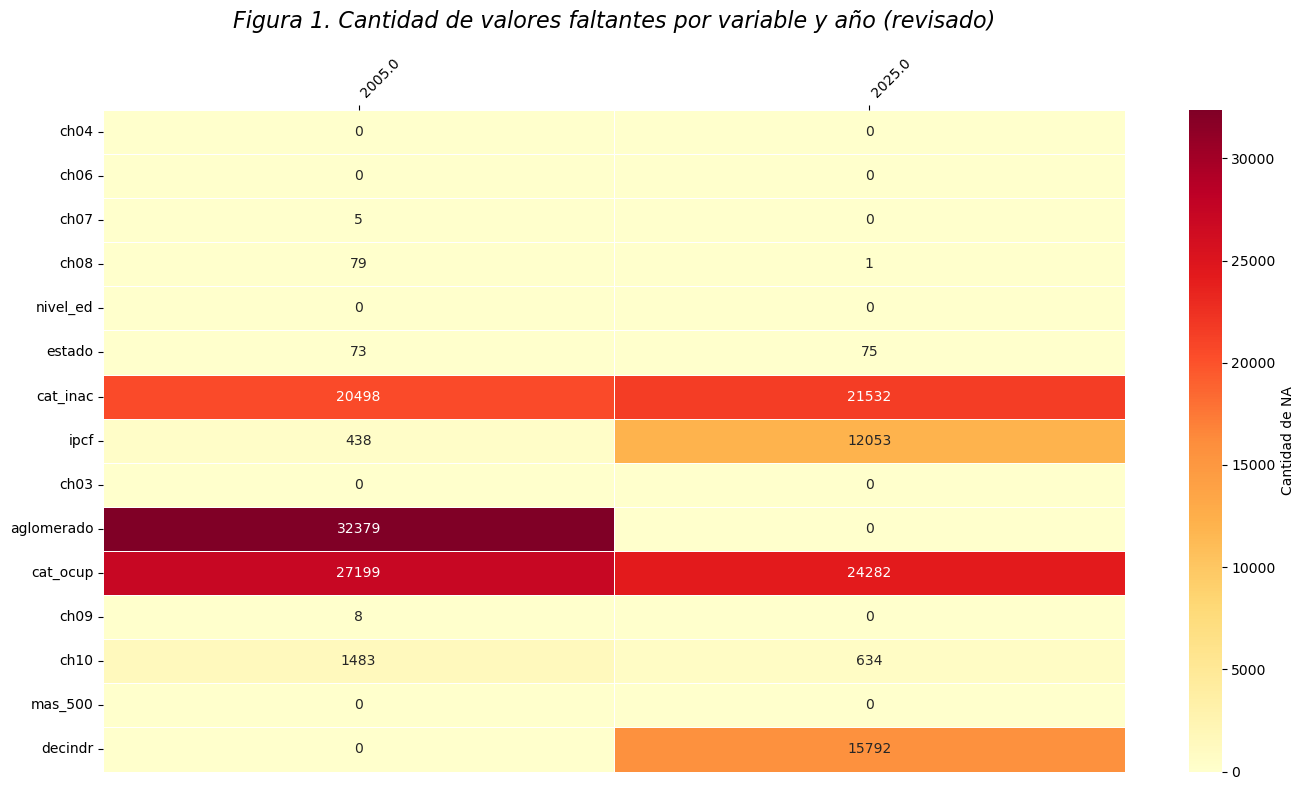

In [24]:
# ==========================================================
# BLOQUE: REVISIÓN Y CONVERSIÓN DE VALORES FALTANTES "OCULTOS"
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Variables de interés
vars_interes = [
    'ch04','ch06','ch07','ch08','nivel_ed','estado',
    'cat_inac','ipcf','ch03','aglomerado','cat_ocup',
    'ch09','ch10','mas_500','decindr'
]

# Crear columna uniforme de año
base_unida['anio'] = base_unida['ano4']

# Convertir valores que podrían representar NA en NaN
# Por ejemplo: 0, "", " ", -1, dependiendo de la codificación de cada variable
valores_na = [0, '', ' ', -1]

for var in vars_interes:
    if var in base_unida.columns:
        base_unida[var] = base_unida[var].replace(valores_na, pd.NA)

# Calcular valores faltantes por año
faltantes = base_unida[vars_interes + ['anio']].groupby('anio').agg(lambda x: x.isna().sum()).T
faltantes.index.name = 'Variable'

# Mostrar tabla de NA
print("\nCantidad de valores faltantes por variable y año (después de revisar valores '0'):")
print(faltantes)

# Identificar variable con más NA por año
for anio in faltantes.columns:
    var_max = faltantes[anio].idxmax()
    cant_max = faltantes[anio].max()
    print(f"\n🔹 Año {anio}: Variable con más NA → {var_max} ({cant_max} NA)")

# Convertir a int para graficar
faltantes_numeric = faltantes.astype(int)

# Heatmap
plt.figure(figsize=(14,8))
ax = sns.heatmap(faltantes_numeric, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
                 cbar_kws={'label': 'Cantidad de NA'})

# Mejorar etiquetas y título
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')
plt.title('Figura 1. Cantidad de valores faltantes por variable y año (revisado)', fontsize=16, fontstyle='italic', pad=20)

plt.tight_layout()
plt.show()




Cantidad de valores faltantes por variable y año:
anio         2005.0   2025.0
Variable                    
ch04            0.0      0.0
ch06            0.0      0.0
ch07            5.0      0.0
ch08           79.0      1.0
nivel_ed        0.0      0.0
estado         73.0     75.0
cat_inac    20498.0  21532.0
ipcf          438.0  12053.0
ch03            0.0      0.0
aglomerado  32379.0      0.0
cat_ocup    27199.0  24282.0
ch09            8.0      0.0
ch10         1483.0    634.0
mas_500         0.0      0.0
decindr         0.0  15792.0

🔹 Año 2005.0: Variable con más NA → aglomerado (32379 NA)

🔹 Año 2025.0: Variable con más NA → cat_ocup (24282 NA)


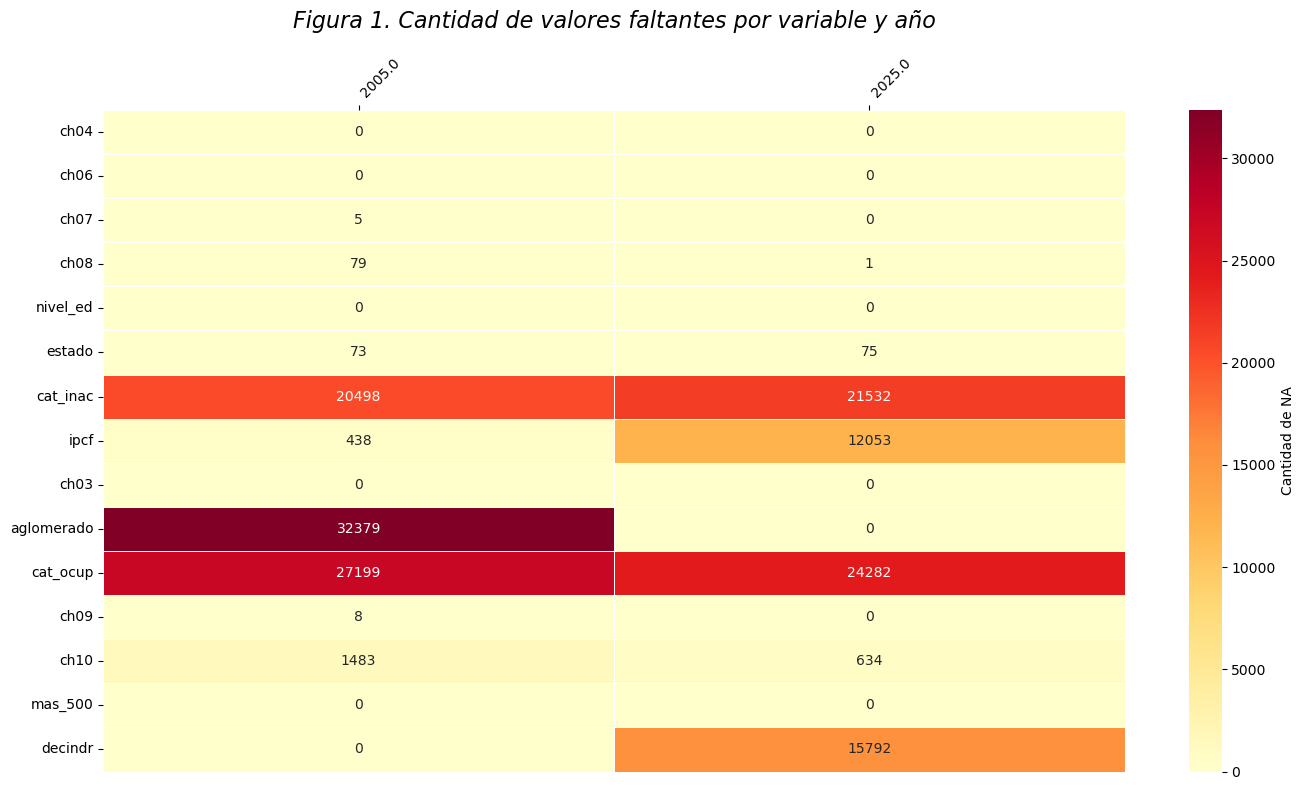

In [27]:
# ==========================================================
# INCISO 2B: HEATMAP DE VALORES FALTANTES + VARIABLES MÁS AFECTADAS
# ==========================================================

import numpy as np

# Crear columna uniforme de año
base_unida['anio'] = base_unida['ano4']

# Reemplazar ceros por NaN en variables donde 0 signifique falta de dato
vars_cero_nan = ['ch04','ch06','ch07','ch08','nivel_ed','estado',
                 'cat_inac','ipcf','ch03','aglomerado','cat_ocup',
                 'ch09','ch10','mas_500','decindr']

for var in vars_cero_nan:
    base_unida[var] = base_unida[var].replace(0, np.nan)

vars_interes = vars_cero_nan  # ya definidas arriba

# Calcular valores faltantes por año
faltantes = base_unida[vars_interes + ['anio']].groupby('anio').agg(lambda x: x.isna().sum()).T
faltantes.index.name = 'Variable'

# Convertir todo a float para evitar problemas con sns.heatmap
faltantes = faltantes.astype(float)

# Mostrar tabla de NA
print("\nCantidad de valores faltantes por variable y año:")
print(faltantes)

# Identificar variable con más NA por año
for anio in faltantes.columns:
    var_max = faltantes[anio].idxmax()
    cant_max = int(faltantes[anio].max())
    print(f"\n🔹 Año {anio}: Variable con más NA → {var_max} ({cant_max} NA)")

# Heatmap
plt.figure(figsize=(14,8))
ax = sns.heatmap(faltantes, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
                 cbar_kws={'label': 'Cantidad de NA'})

# Mejorar etiquetas y título
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')
plt.title('Figura 1. Cantidad de valores faltantes por variable y año', fontsize=16, fontstyle='italic', pad=20)

plt.tight_layout()
plt.show()


2.c.	Corregir variables si notan valores sin sentido (como ingresos negativos) de acuerdo a la documentación de la EPH (puede ser una codificación de no respuesta de los individuos) y eliminen estos valores extraños de sus 15 variables de interés. Comenten brevemente en el reporte dicho proceso de limpieza.

In [28]:
# ==========================================================
# INCISO 2C: LIMPIEZA DE VARIABLES DE INTERÉS
# ==========================================================

# Lista de variables numéricas de interés
vars_numericas = ['ch04','ch06','ch07','ch08','nivel_ed','estado',
                  'cat_inac','ipcf','ch03','aglomerado','cat_ocup','ch09','ch10']

# Crear copia para no alterar la base original
base_limpia = base_unida.copy()

# Definir condiciones de limpieza (ejemplo: ingresos negativos, códigos de no respuesta)
# Según documentación EPH: valores negativos suelen indicar "no responde" o "no aplica"
# Vamos a aplicar limpieza solo a las variables numéricas
for var in vars_numericas:
    if var in base_limpia.columns:
        # Convertir a numeric en caso de que no lo sea
        base_limpia[var] = pd.to_numeric(base_limpia[var], errors='coerce')
        # Eliminar valores negativos
        n_invalidos = (base_limpia[var] < 0).sum()
        if n_invalidos > 0:
            print(f"Variable {var}: {n_invalidos} valores negativos reemplazados por NaN")
            base_limpia.loc[base_limpia[var] < 0, var] = np.nan

# Verificación: mostrar primeras filas y conteo de NA por variable
print("\nConteo de NA después de limpieza:")
print(base_limpia[vars_numericas].isna().sum())

# Exportar base de datos a csv y excel
# Exportar a CSV
base_limpia.to_csv('base_final.csv', index=False)
# Exportar a Excel
base_limpia.to_excel('base_final.xlsx', index=False)


Variable ch06: 290 valores negativos reemplazados por NaN

Conteo de NA después de limpieza:
ch04              0
ch06           1013
ch07              5
ch08             80
nivel_ed          0
estado          148
cat_inac      42030
ipcf          12491
ch03              0
aglomerado    32379
cat_ocup      51481
ch09              8
ch10           2117
dtype: int64


# Parte II: Primer Análisis Exploratorio

3.	Realicen un gráfico de barras mostrando la composición por sexo para 2005 y 2025 en su región. Comenten los resultados.

📊 Porcentaje de personas por sexo en la región seleccionada:


sexo,Mujer,Varón
2005,52.20,47.80
2025,51.97,48.03



📈 Diferencia porcentual 2025 vs 2005:


,Diferencia (%)
sexo,
Mujer,-0.23
Varón,0.23


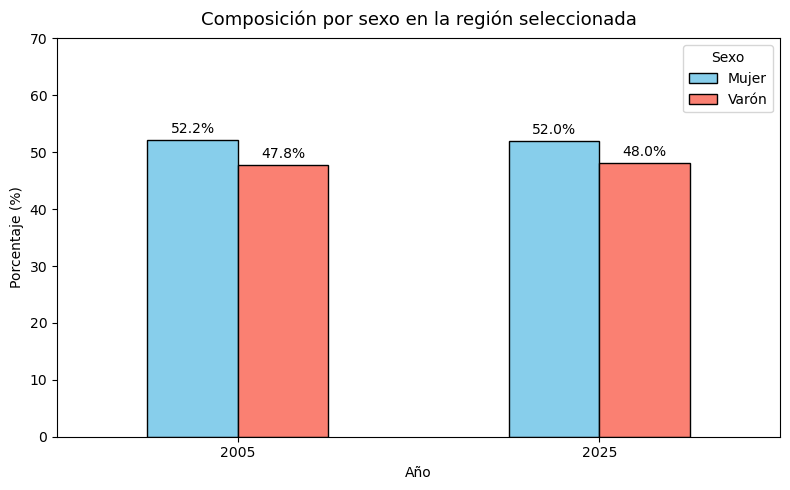

In [29]:
# ==========================================================
# INCISO 3️⃣: COMPOSICIÓN POR SEXO – CON ETIQUETAS DE %
# ==========================================================

# Asegurarse de que la variable sexo exista y esté en formato categórico
if 'ch04' in base_limpia.columns:  # ch04 = sexo
    base_limpia['sexo'] = base_limpia['ch04'].map({1: 'Varón', 2: 'Mujer'}).astype('category')

# Filtrar por año
base_2005_sexo = base_limpia[base_limpia['anio'] == 2005]
base_2025_sexo = base_limpia[base_limpia['anio'] == 2025]

# Contar frecuencia por sexo
freq_2005 = base_2005_sexo['sexo'].value_counts(normalize=True) * 100
freq_2025 = base_2025_sexo['sexo'].value_counts(normalize=True) * 100

# =============================
# 📊 RESULTADOS TABULARES
# =============================
tabla_sexo = pd.concat([
    freq_2005.rename('2005'),
    freq_2025.rename('2025')
], axis=1).T.round(2)

print("📊 Porcentaje de personas por sexo en la región seleccionada:")
display(tabla_sexo)

# Diferencia porcentual entre años
tabla_sexo_diff = (tabla_sexo.loc['2025'] - tabla_sexo.loc['2005']).rename('Diferencia (%)').to_frame()
print("\n📈 Diferencia porcentual 2025 vs 2005:")
display(tabla_sexo_diff)

# Crear dataframe para graficar
df_sexo = pd.DataFrame({'2005': freq_2005, '2025': freq_2025}).T

# Gráfico de barras
ax = df_sexo.plot(
    kind='bar',
    figsize=(8,5),
    color=['skyblue','salmon'],
    edgecolor='black'
)

plt.title('Composición por sexo en la región seleccionada', fontsize=13, pad=10)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Año')
plt.xticks(rotation=0)
plt.legend(title='Sexo')
plt.ylim(0, 70)

# Añadir etiquetas de porcentaje encima de las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=10, padding=3)

plt.tight_layout()
plt.show()


4.	Realicen una matriz de correlación para 2005 y 2025 con las siguientes variables: CH04, CH06, CH07, CH08, NIVEL ED, ESTADO, CAT_INAC, IPCF. Crear las variables dicotómicas binarias necesarias (variables dummies) y renombrar dichas variables para que las etiquetas tengan sentido en el gráfico de correlación. Utilicen alguno de los comandos disponibles en este link para graficar la matriz de correlación. Comenten los resultados. 

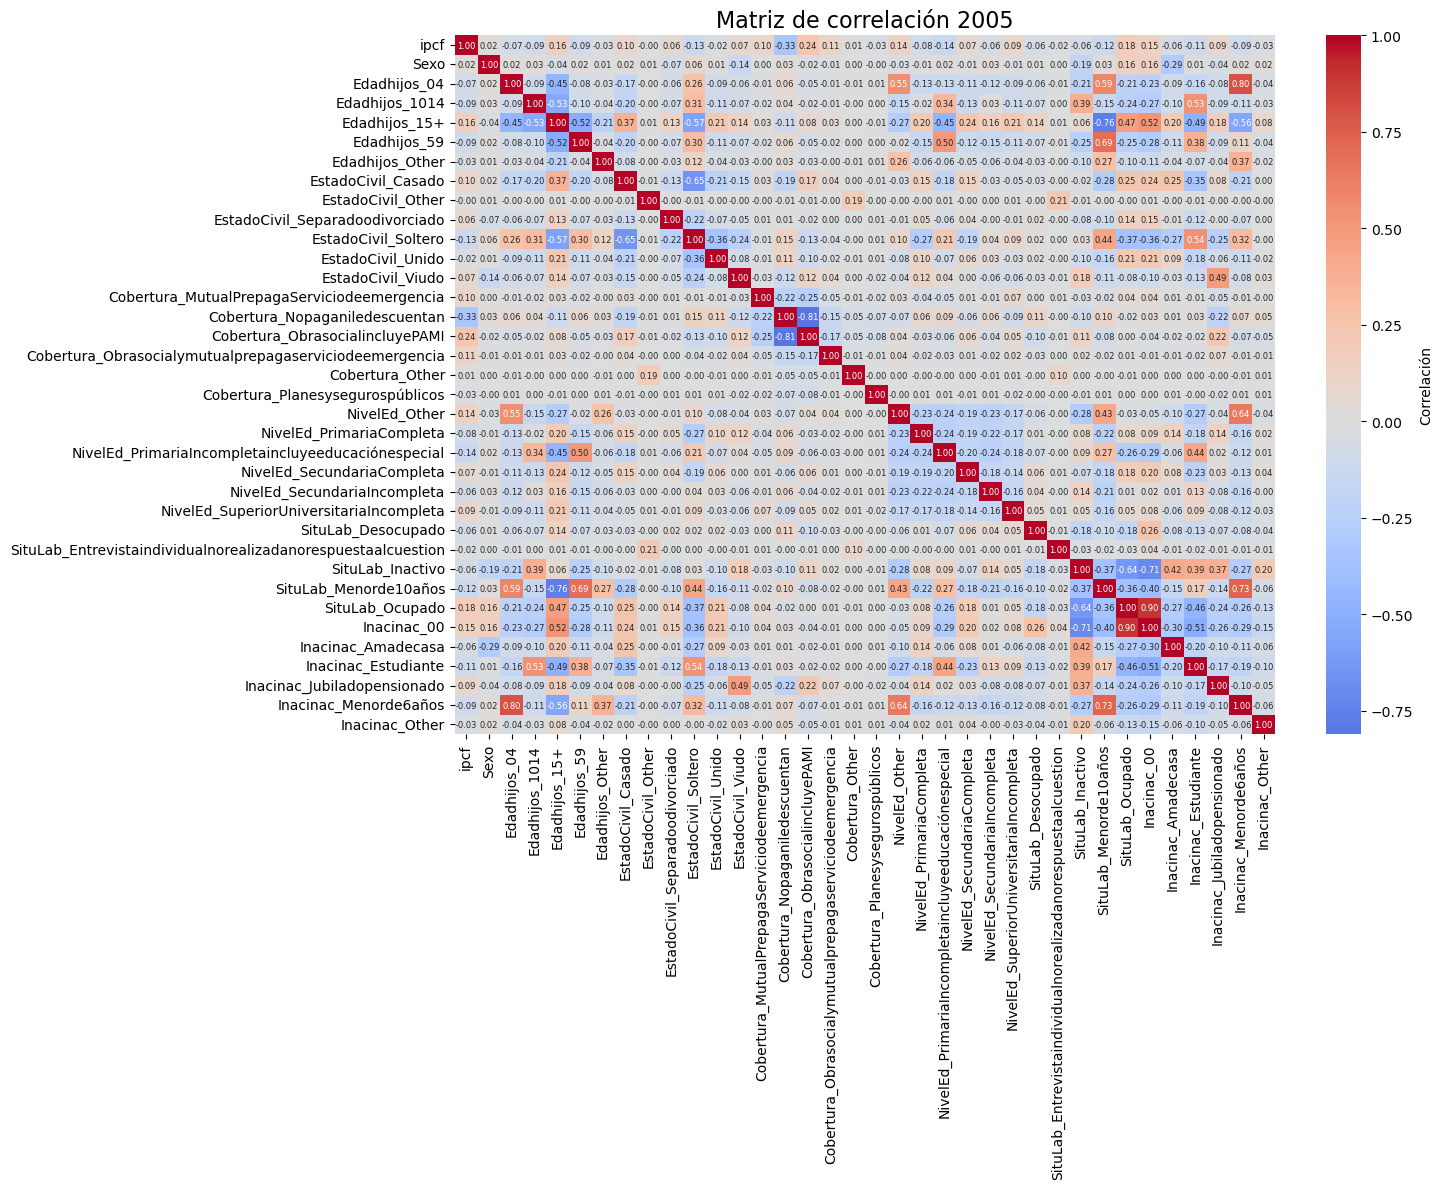

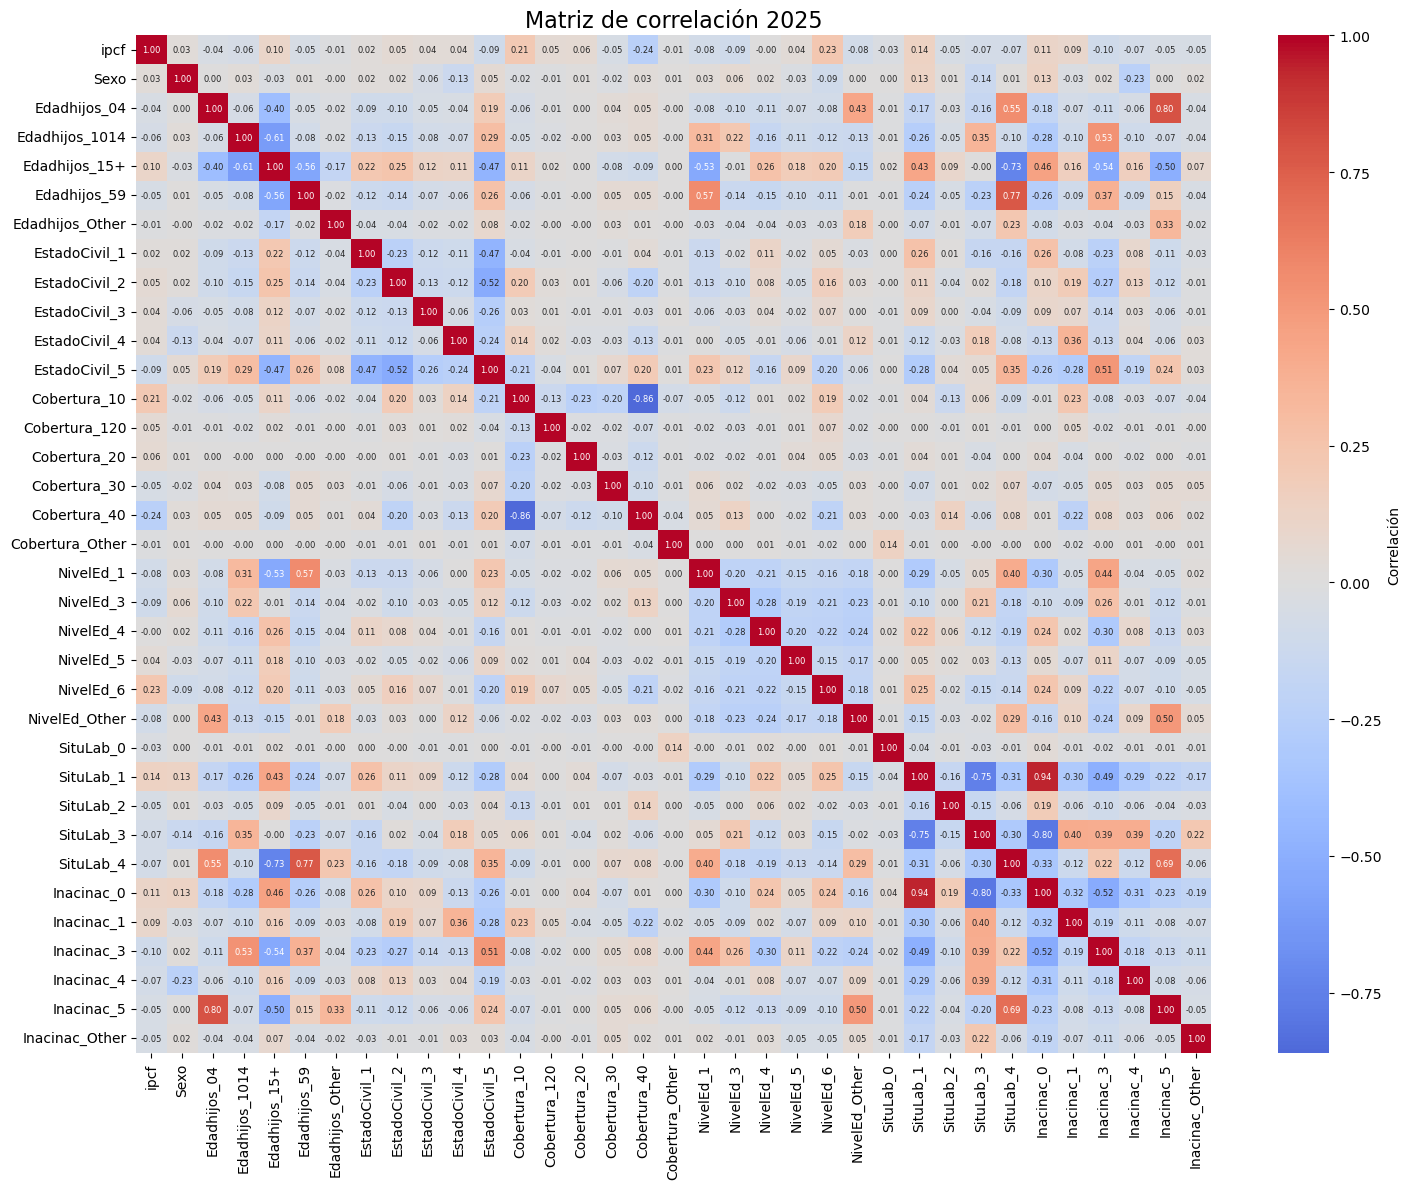

Top 5 correlaciones 2005:
SituLab_Ocupado                 Inacinac_00                        0.90
Cobertura_Nopaganiledescuentan  Cobertura_ObrasocialincluyePAMI    0.81
Edadhijos_04                    Inacinac_Menorde6años              0.80
Edadhijos_15+                   SituLab_Menorde10años              0.76
SituLab_Menorde10años           Inacinac_Menorde6años              0.73
dtype: float64

Top 5 correlaciones 2025:
SituLab_1     Inacinac_0      0.94
Cobertura_10  Cobertura_40    0.86
Edadhijos_04  Inacinac_5      0.80
Edadhijos_59  SituLab_4       0.77
SituLab_1     SituLab_3       0.75
dtype: float64


In [32]:
import pandas as pd
import numpy as np

# -------------------------------
# Función para limpiar etiquetas
# -------------------------------
def clean_label(label):
    """
    Elimina espacios, mayúsculas y caracteres especiales de una etiqueta
    """
    return str(label).replace(' ', '').replace('/', '').replace('.', '').replace('-', '').replace(',', '').replace('(', '').replace(')', '')

# -------------------------------
# Función para agrupar CH06 (edad)
# -------------------------------
def ch06_to_bins(series):
    """
    Agrupa CH06 en bins legibles para la correlación y conserva NA como 'Other'
    """
    s = pd.to_numeric(series, errors='coerce')  # convierte a numérico, NA si no es posible
    bins_edges = [0, 4, 9, 14, 100]
    labels = ['0-4', '5-9', '10-14', '15+']
    
    s_bin = pd.cut(s, bins=bins_edges, labels=labels, right=True)
    s_bin = s_bin.astype(str).replace('nan', 'Other')  # valores NA o fuera de rango
    s_bin = s_bin.apply(clean_label)
    return s_bin

# -------------------------------
# Función principal para preparar datos
# -------------------------------
def preparar_para_corr(df):
    df = df.copy()
    
    # -------------------------------
    # 1) Convertir CH04 a numérico (sexo)
    # -------------------------------
    if 'ch04' in df.columns:
        df['ch04'] = df['ch04'].astype(str).str.strip().str.lower()
        df['Sexo'] = df['ch04'].map({
            'varón':1, 'hombre':1, '1':1,
            'mujer':0, '2':0
        })
        df['Sexo'] = df['Sexo'].astype('Int64')  # mantiene NA si no se puede asignar
    
    # -------------------------------
    # 2) CH06 -> agrupar en bins
    # -------------------------------
    if 'ch06' in df.columns:
        df['Edadhijos'] = ch06_to_bins(df['ch06'])
    
    # -------------------------------
    # 3) CH07 -> Estado Civil top 5 + Other
    # -------------------------------
    if 'ch07' in df.columns:
        df['ch07'] = df['ch07'].astype(str)
        top_ch07 = df['ch07'].value_counts().nlargest(5).index
        df['EstadoCivil'] = df['ch07'].where(df['ch07'].isin(top_ch07), 'Other').apply(clean_label)
    
    # -------------------------------
    # 4) CH08 -> Cobertura de salud top 5 + Other
    # -------------------------------
    if 'ch08' in df.columns:
        df['ch08'] = df['ch08'].astype(str)
        top_ch08 = df['ch08'].value_counts().nlargest(5).index
        df['Cobertura'] = df['ch08'].where(df['ch08'].isin(top_ch08), 'Other').apply(clean_label)
    
    # -------------------------------
    # 5) NIVEL_ED -> top 5 + Other
    # -------------------------------
    if 'nivel_ed' in df.columns:
        df['nivel_ed'] = df['nivel_ed'].astype(str)
        top_ed = df['nivel_ed'].value_counts().nlargest(5).index
        df['NivelEd'] = df['nivel_ed'].where(df['nivel_ed'].isin(top_ed), 'Other').apply(clean_label)
    
    # -------------------------------
    # 6) ESTADO -> top 5 + Other
    # -------------------------------
    if 'estado' in df.columns:
        df['estado'] = df['estado'].astype(str)
        top_est = df['estado'].value_counts().nlargest(5).index
        df['SituLab'] = df['estado'].where(df['estado'].isin(top_est), 'Other').apply(clean_label)
    
    # -------------------------------
    # 7) CAT_INAC -> top 5 + Other
    # -------------------------------
    if 'cat_inac' in df.columns:
        df['cat_inac'] = df['cat_inac'].astype(str)
        top_inac = df['cat_inac'].value_counts().nlargest(5).index
        df['Inacinac'] = df['cat_inac'].where(df['cat_inac'].isin(top_inac), 'Other').apply(clean_label)
    
    # -------------------------------
    # 8) Crear dummies para categóricas nuevas
    # -------------------------------
    cat_vars = ['Edadhijos','EstadoCivil','Cobertura','NivelEd','SituLab','Inacinac']
    df_dummies = pd.get_dummies(df[cat_vars], prefix=cat_vars)
    
    # -------------------------------
    # 9) Seleccionar variables numéricas
    # -------------------------------
    num_vars = ['ipcf','Sexo']
    
    df_final = pd.concat([df[num_vars], df_dummies], axis=1)
    return df_final

# -------------------------------
# 10) Ejecutar preparación para 2005 y 2025
# -------------------------------
df2005_corr = preparar_para_corr(base_2005_region)
df2025_corr = preparar_para_corr(base_2025_region)

# -------------------------------
# 11) Calcular matrices de correlación
# -------------------------------
corr_2005 = df2005_corr.corr().round(2)
corr_2025 = df2025_corr.corr().round(2)



import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Función para graficar heatmap de correlación
# -------------------------------
def plot_corr_heatmap(corr_matrix, title, filename=None):
    """
    Grafica un heatmap de la matriz de correlación
    """
    plt.figure(figsize=(15,12))
    sns.heatmap(
        corr_matrix,
        cmap='coolwarm',
        center=0,
        annot=True,
        fmt=".2f",
        annot_kws={"size":6},
        cbar_kws={'label':'Correlación'}
    )
    plt.title(title, fontsize=16)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# -------------------------------
# Graficar heatmaps
# -------------------------------
plot_corr_heatmap(corr_2005, "Matriz de correlación 2005", "matriz_correlacion_2005.png")
plot_corr_heatmap(corr_2025, "Matriz de correlación 2025", "matriz_correlacion_2025.png")

# -------------------------------
# Top 5 correlaciones en valor absoluto
# -------------------------------
def top_correlations(corr_matrix, top_n=5):
    corr_matrix_values = corr_matrix.abs().unstack()
    corr_matrix_values = corr_matrix_values[corr_matrix_values < 1]  # eliminar diagonal
    corr_matrix_values = corr_matrix_values.drop_duplicates()
    return corr_matrix_values.sort_values(ascending=False).head(top_n)

print("Top 5 correlaciones 2005:")
print(top_correlations(corr_2005))

print("\nTop 5 correlaciones 2025:")
print(top_correlations(corr_2025))




In [ ]:
# Parte III: Conociendo a los pobres y no pobres.

5.	Uno de los grandes problemas de la EPH es la creciente cantidad de hogares que no reportan sus ingresos (ver por ejemplo el siguiente informe). ¿Cuántas personas no respondieron cuál es su condición de actividad? Guarden como una base distinta llamada respondieron las observaciones donde respondieron la pregunta sobre su ingreso total familiar (ITF). Las observaciones con ITF=0 guárdenlas en una base bajo el nombre norespondieron.

In [ ]:
# ==========================================================
# INCISO 5️⃣: PERSONAS QUE RESPONDIERON O NO RESPONDIERON ITF
# ==========================================================

# Ajustamos a numeric por si hubiera inconsistencias
base_limpia['ipcf'] = pd.to_numeric(base_limpia['ipcf'], errors='coerce')

# Base de personas que respondieron ITF (IPCF > 0)
respondieron = base_limpia[base_limpia['ipcf'] > 0].copy()

# Base de personas que no respondieron ITF (IPCF = 0 o NA)
norespondieron = base_limpia[base_limpia['ipcf'].fillna(0) == 0].copy()

# Conteo por año
conteo_respondieron = respondieron.groupby('anio').size()
conteo_norespondieron = norespondieron.groupby('anio').size()

print("🔹 Personas que respondieron ITF:")
print(conteo_respondieron)
print("\n🔹 Personas que NO respondieron ITF:")
print(conteo_norespondieron)

# ==========================================================
# Guardado de las bases
# ==========================================================

# Ruta de guardado (modificá según corresponda)
ruta_base = r"C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3\TP01"

# Guardar CSV
respondieron.to_csv(f"{ruta_base}\\respondieron_ITF.csv", index=False)
norespondieron.to_csv(f"{ruta_base}\\norespondieron_ITF.csv", index=False)

print("\n✅ Bases guardadas correctamente en CSV")


6.	Utilizando el archivo tabla_adulto_equiv.xlsx, agreguen a su base de datos una columna llamada adulto_equiv que contenga los valores de adulto equivalente de cada persona según su sexo y edad (por ejemplo, a un varón de 2 años le corresponde 0.46). Finalmente, con el comando groupby sumen esta nueva columna para las personas que pertenecen a un mismo hogar y guarden ese dato en una columna llamada ad_equiv_hogar .

In [40]:
# ==========================================================
# INCISO 6️⃣: CALCULO DE ADULTOS EQUIVALENTES
# ==========================================================

# BLOQUE 1: Cargar y limpiar la tabla de adultos equivalentes

import pandas as pd
import numpy as np

ruta_tabla = r"C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3\TP01\tabla_adulto_equiv.xlsx"
tabla_adulto = pd.read_excel(ruta_tabla, skiprows=4)  # saltamos filas innecesarias
tabla_adulto.columns = ['edad', 'mujeres', 'varones']

print("Primeras filas de tabla de adultos equivalentes:")
print(tabla_adulto.head())

Primeras filas de tabla de adultos equivalentes:
             edad  mujeres  varones
0  Menor de 1 año     0.35     0.35
1            1año     0.37     0.37
2          2 años     0.46     0.46
3          3 años     0.51     0.51
4          4 años     0.55     0.55


In [41]:
# ================================
# BLOQUE 2: Transformar tabla a formato largo
# ================================
tabla_adulto['edad'] = tabla_adulto['edad'].astype(str).str.strip()

tabla_adulto_melt = tabla_adulto.melt(
    id_vars='edad', 
    value_vars=['mujeres', 'varones'], 
    var_name='sexo_texto', 
    value_name='adulto_equiv'
)

print("Primeras filas de tabla en formato largo:")
print(tabla_adulto_melt.head(10))


Primeras filas de tabla en formato largo:
             edad sexo_texto  adulto_equiv
0  Menor de 1 año    mujeres          0.35
1            1año    mujeres          0.37
2          2 años    mujeres          0.46
3          3 años    mujeres          0.51
4          4 años    mujeres          0.55
5          5 años    mujeres          0.60
6          6 años    mujeres          0.64
7          7 años    mujeres          0.66
8          8 años    mujeres          0.68
9          9 años    mujeres          0.69


In [39]:
import pandas as pd
import numpy as np

# ==========================================================
# 1️⃣ Cargar tabla adultos equivalentes
# ==========================================================
ruta_tabla = r"C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3\TP01\tabla_adulto_equiv.xlsx"
tabla_adulto = pd.read_excel(ruta_tabla, skiprows=4)

# Renombrar columnas y limpiar
tabla_adulto.columns = ['edad', 'mujeres', 'varones']
tabla_adulto['edad'] = tabla_adulto['edad'].astype(str).str.strip()

# Melt para normalizar
tabla_adulto_melt = tabla_adulto.melt(
    id_vars='edad',
    value_vars=['mujeres','varones'],
    var_name='sexo_texto',
    value_name='adulto_equiv'
)

tabla_adulto_melt['edad'] = tabla_adulto_melt['edad'].str.replace(' ','').str.lower()
tabla_adulto_melt['sexo_texto'] = tabla_adulto_melt['sexo_texto'].str.lower().str.strip()
tabla_adulto_melt['adulto_equiv'] = pd.to_numeric(tabla_adulto_melt['adulto_equiv'], errors='coerce')
tabla_adulto_melt = tabla_adulto_melt.dropna(subset=['edad','adulto_equiv'])

# ==========================================================
# 2️⃣ Limpiar base 'respondieron'
# ==========================================================
# Normalizar sexo
respondieron['sexo_texto'] = respondieron['sexo'].astype(str).str.lower().str.strip()
respondieron['sexo_texto'] = respondieron['sexo_texto'].replace({
    'varón':'varones', 'varon':'varones', 'mujer':'mujeres', 'nan': pd.NA
})
respondieron['sexo_texto'] = respondieron['sexo_texto'].fillna('varones')  # default

# Mapear edad a string para merge
def map_edad_ch06(x):
    if pd.isna(x):
        return 'other'
    x = int(x)
    if x == 0:
        return 'menorde1año'
    elif x == 1:
        return '1año'
    else:
        return f"{x}años"

respondieron['edad_str'] = respondieron['ch06'].apply(map_edad_ch06)
respondieron['edad_str'] = respondieron['edad_str'].str.replace(' ','').str.lower()

# ==========================================================
# 3️⃣ Merge con adultos equivalentes
# ==========================================================
# Evitar columnas duplicadas
for col in ['adulto_equiv','edad']:
    if col in respondieron.columns:
        respondieron = respondieron.drop(columns=[col])

# Merge con tabla de adultos equivalentes
respondieron = respondieron.merge(
    tabla_adulto_melt,
    left_on=['edad_str','sexo_texto'],
    right_on=['edad','sexo_texto'],
    how='left'
)

# Asignar valor por defecto para filas sin match
respondieron['adulto_equiv'] = respondieron['adulto_equiv'].fillna(1)

# ==========================================================
# 4️⃣ Calcular adultos equivalentes por hogar
# ==========================================================
respondieron['ad_equiv_hogar'] = respondieron.groupby('nro_hogar')['adulto_equiv'].transform('sum')

# ==========================================================
# 5️⃣ Revisar resultados
# ==========================================================
print("Filas sin adulto_equiv después de fillna:", respondieron['adulto_equiv'].isna().sum())
print(respondieron[['nro_hogar','ch03','edad_str','sexo_texto','adulto_equiv','ad_equiv_hogar']].head(10))

# ==========================================================
# 6️⃣ Guardar en CSV 
# ==========================================================
ruta_guardado_csv = r"C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3\TP01\respondieron_adultos_equiv.csv"
respondieron.to_csv(ruta_guardado_csv, index=False, sep=';', encoding='utf-8')
print("✅ Base 'respondieron' guardada correctamente en CSV.")


Filas sin adulto_equiv después de fillna: 0
   nro_hogar  ch03 edad_str sexo_texto  adulto_equiv  ad_equiv_hogar
0        1.0     1   80años    varones           1.0        71192.29
1        1.0     1   26años    varones           1.0        71192.29
2        1.0     2   27años    mujeres           1.0        71192.29
3        1.0     3    other    mujeres           1.0        71192.29
4        1.0     1   71años    mujeres           1.0        71192.29
5        1.0     1   54años    varones           1.0        71192.29
6        1.0     2   54años    mujeres           1.0        71192.29
7        1.0     3   27años    mujeres           1.0        71192.29
8        1.0     3   20años    varones           1.0        71192.29
9        1.0     3   18años    mujeres           1.0        71192.29
✅ Base 'respondieron' guardada correctamente en CSV.


In [42]:
# ================================
# BLOQUE 5: Sumar adulto_equiv por hogar
# ================================
respondieron['ad_equiv_hogar'] = respondieron.groupby('codusu')['adulto_equiv'].transform('sum')

print("Verificación de adultos equivalentes por hogar:")
print(respondieron[['codusu', 'adulto_equiv', 'ad_equiv_hogar']].head(10))

Verificación de adultos equivalentes por hogar:
     codusu  adulto_equiv  ad_equiv_hogar
0  125098             1.0             1.0
1  125188             1.0             3.0
2  125188             1.0             3.0
3  125188             1.0             3.0
4  125242             1.0             1.0
5  125436             1.0             5.0
6  125436             1.0             5.0
7  125436             1.0             5.0
8  125436             1.0             5.0
9  125436             1.0             5.0


7.	Sabiendo que la Canasta Básica Total para un adulto equivalente en el primer trimestre de 2025 es aproximadamente $365.177, agreguen a la base respondieron una columna llamada ingreso_necesario que sea el producto de este valor por ad_equiv_hogar. Para el primer trimestre de 2005 la Canasta Básica Total para un adulto equivalente era aproximadamente $205,07. Note que este es el valor mínimo que necesita ese hogar para no ser pobre.

In [43]:
# ==============================
# 7️⃣ INCISO 7: Calcular ingreso necesario por hogar (por año)
# ==============================

# Constantes (adulto equivalente)
CBT_2005 = 205.07
CBT_2025 = 365_177.0

# Aseguro que la columna de año se llame ano4 (sin crear dataframes nuevos)
if 'ano4' not in respondieron.columns and 'ANO4' in respondieron.columns:
    respondieron = respondieron.rename(columns={'ANO4':'ano4'})

# Asignar CBT por AÑO (sin trimestre)
cbt_por_anio = {2005: CBT_2005, 2025: CBT_2025}
respondieron['cbt_ae'] = respondieron['ano4'].map(cbt_por_anio)

# Ingreso necesario del hogar = CBT_AE * AE del hogar
respondieron['ingreso_necesario'] = respondieron['cbt_ae'] * respondieron['ad_equiv_hogar']

# (Chequeo rápido)
print(respondieron[['ano4','cbt_ae']].drop_duplicates().sort_values('ano4'))
print("Registros sin CBT:", respondieron['cbt_ae'].isna().sum())


         ano4     cbt_ae
0      2005.0     205.07
46592  2025.0  365177.00
Registros sin CBT: 0


In [48]:
# ==========================================================
# 7️⃣ Agregar columna ingreso necesario por hogar
# ==========================================================

# Definir valores de Canasta Básica Total por adulto equivalente
cbt_por_ano = {
    2005: 205.07,
    2025: 365177.00
}

# Crear columna ingreso_necesario
respondieron['ingreso_necesario'] = respondieron['anio'].map(cbt_por_ano) * respondieron['ad_equiv_hogar']

# Revisar resultados
print(respondieron[['anio','ad_equiv_hogar','ingreso_necesario']].head(10))

# Verificar registros sin valor de CBT
sin_cbt = respondieron['ingreso_necesario'].isna().sum()
print(f"Registros sin CBT: {sin_cbt}")


# ==========================================================
# Guardar base final con ingreso_necesario en CSV
# ==========================================================
ruta_csv = r"C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3\TP01\respondieron_adultos_equiv_ingreso.csv"
respondieron.to_csv(ruta_csv, index=False)
print("✅ Base final guardada correctamente en CSV.")



     anio  ad_equiv_hogar  ingreso_necesario
0  2005.0             1.0             205.07
1  2005.0             3.0             615.21
2  2005.0             3.0             615.21
3  2005.0             3.0             615.21
4  2005.0             1.0             205.07
5  2005.0             5.0            1025.35
6  2005.0             5.0            1025.35
7  2005.0             5.0            1025.35
8  2005.0             5.0            1025.35
9  2005.0             5.0            1025.35
Registros sin CBT: 0
✅ Base final guardada correctamente en CSV.


8.	Por último, agreguen a respondieron una columna llamada pobre que tome valor 1 si el ITF es menor al ingreso necesario que necesita esa familia, y 0 en caso contrario. ¿Cuántos pobres identificaron para cada año? ¿Qué porcentaje de la muestra representa?

In [49]:
# ==============================
# 8️⃣ INCISO 8: Identificar hogares pobres 
# ==============================

# Crear columna 'pobre': 1 si ITF < ingreso_necesario, 0 si no
respondieron['pobre'] = np.where(respondieron['itf'] < respondieron['ingreso_necesario'], 1, 0) 

# Cantidad de pobres
num_pobres = respondieron['pobre'].sum()

# Porcentaje de la muestra
porc_pobres = respondieron['pobre'].mean() * 100

print(f"Cantidad de pobres: {num_pobres}")
print(f"Porcentaje de la muestra: {porc_pobres:.2f}%")


Cantidad de pobres: 33948
Porcentaje de la muestra: 42.45%


In [50]:
# Agrupar por año
resumen = respondieron.groupby('anio').agg(
    pobres=('pobre','sum'),
    personas=('pobre','count')
).reset_index()

resumen['porc_muestra_pct'] = (resumen['pobres'] / resumen['personas'] * 100)

# Mostrar por año
for y in [2005, 2025]:
    fila = resumen.loc[resumen['anio'] == y]
    if not fila.empty:
        pobres   = int(fila['pobres'].iloc[0])
        personas = int(fila['personas'].iloc[0])
        p_mue    = fila['porc_muestra_pct'].iloc[0]
        print(f"Año {y}: pobres={pobres}, personas={personas}, %muestra={p_mue:.2f}%")


Año 2005: pobres=18608, personas=46592, %muestra=39.94%
Año 2025: pobres=15340, personas=33372, %muestra=45.97%


9.	(Opcional) Muestren estadísticas descriptivas relevantes de pobre en una tabla, comparando 2005 con 2025. Además, hagan 2 gráficos exploratorios a elección usando la variable pobre. Comenten. tulo

In [51]:
# ============================== 
# 9️⃣ INCISO OPCIONAL: Estadísticas descriptivas y gráficos de pobreza 
# ==============================

# 🔹 Estadísticas descriptivas básicas de la variable 'pobre'
# Contamos cuántos pobres y no pobres
stats_pobre = respondieron['pobre'].value_counts().rename_axis('pobre').reset_index(name='cantidad')

# Calculamos porcentaje
stats_pobre['porcentaje'] = stats_pobre['cantidad'] / stats_pobre['cantidad'].sum() * 100

# Mostramos tabla
print(stats_pobre)


   pobre  cantidad  porcentaje
0      0     46016   57.545896
1      1     33948   42.454104


In [52]:
stats_pobre_anio = (
    respondieron
    .groupby(['ano4','pobre'])
    .size()
    .rename('cantidad')
    .reset_index()
)
stats_pobre_anio['porcentaje'] = (
    stats_pobre_anio
    .groupby('ano4')['cantidad']
    .transform(lambda s: 100 * s / s.sum())
)

# Tabla ordenada
print(stats_pobre_anio.sort_values(['ano4','pobre']))


     ano4  pobre  cantidad  porcentaje
0  2005.0      0     27984   60.061813
1  2005.0      1     18608   39.938187
2  2025.0      0     18032   54.033321
3  2025.0      1     15340   45.966679


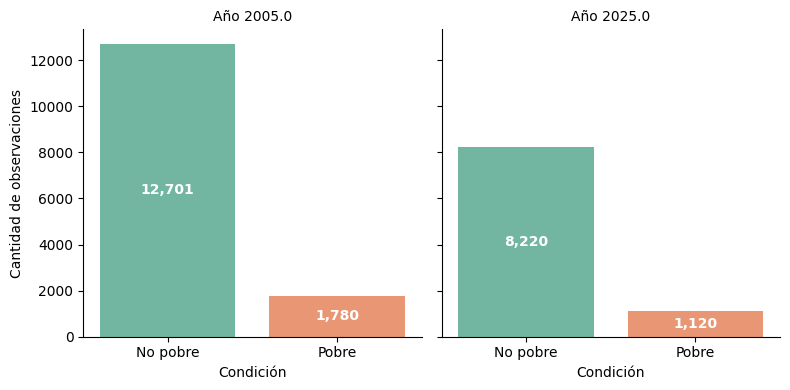

In [69]:
g = sns.catplot(
    data=respondieron, x='pobre', col='ano4',
    kind='count', palette='Set2', sharey=True, height=4, aspect=1
)
for ax in g.axes.flat:
    ax.set_xticklabels(['No pobre','Pobre'])
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.text(p.get_x()+p.get_width()/2, h/2, f'{int(h):,}',
                    ha='center', va='center', color='white', fontweight='bold')
g.set_titles('Año {col_name}')
g.set_axis_labels('Condición','Cantidad de observaciones')
plt.tight_layout()
plt.show()

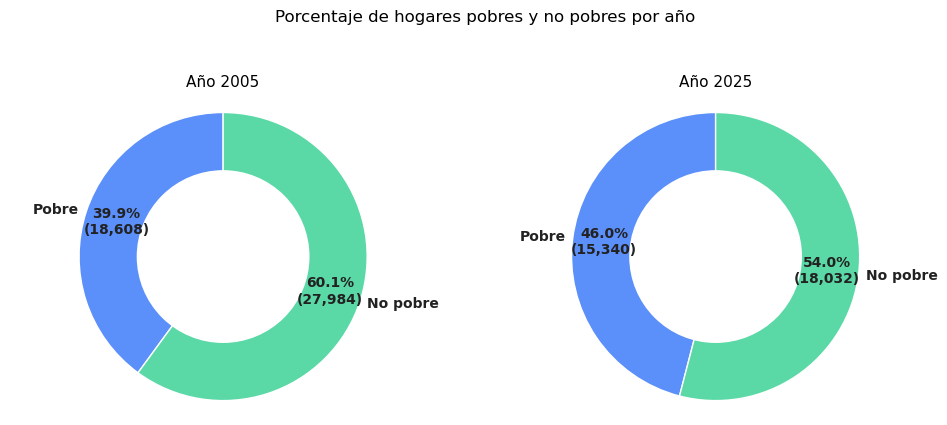

In [53]:
labels = ['Pobre', 'No pobre']
palette = ['#5B8FF9', '#5AD8A6']  # lindo combo: azul suave + verde menta

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, year in zip(axes, [2005, 2025]):
    sub = respondieron.loc[respondieron['ano4'] == year]
    counts = sub['pobre'].value_counts().reindex([1, 0]).fillna(0)
    total = counts.sum()

    def autopct(pct):
        if pct <= 0:
            return ''
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:,})'

    wedges, texts, autotexts = ax.pie(
        counts,
        labels=labels,
        colors=palette,
        autopct=autopct,
        startangle=90,
        pctdistance=0.78,
        labeldistance=1.05,
        wedgeprops=dict(edgecolor='white', linewidth=1),
        textprops=dict(color='#222', fontsize=10, weight='bold')
    )

    # Donut style (queda más prolijo)
    centre_circle = plt.Circle((0, 0), 0.60, fc='white')
    ax.add_artist(centre_circle)
    ax.axis('equal')
    ax.set_title(f'Año {year}', fontsize=11, pad=8)

plt.suptitle('Porcentaje de hogares pobres y no pobres por año', fontsize=12, y=1.05)
plt.tight_layout()
plt.show()






